# Life Expendancy Analysis

This notebook aims at taking a deep dive into the life expectancy dataset.
*TODO: Expand this*

> NOTE: MUST SLIGHTLY MODIFY THE DICTIONARY SO THAT IT PROPERLY MAPS Congo (Congo & Congo, The republic of) 

In [14]:
''' Necessary Imports '''
import pandas as pd  # Dataframe handling
import numpy as np  # Mathematical operations
import plotly.graph_objects as go  # Graphing/Interactive visualizations
import missingno as msno  # For making a nullity matrix
import pycountry  # Deriving ISO-3 country codes

## Problem 1: Loading and Initial Cleaning of the Data

Firstly, we must load the data from the provided Life Expectancy csv file, then perform the initial basic cleaning operations to strip leading/trailing whitespaces from column names.

In [4]:
# Load the dataset as a pandas dataframe
DATA_PATH: str = './data/Life Expectancy Data.csv'  # Path to the dataset
df = pd.read_csv(DATA_PATH)

# Strip all leading/trailing whitespaces from column names
df.columns = df.columns.str.strip()

# Verifying that all column names have been cleaned
print(df.columns)  # Directly print the columns
# Print if any column name has a leading or trailing whitespace
for col in df.columns:
    curCol = str(col)
    if curCol[0] == ' ' or curCol[-1] == ' ':
        print(f"Whitespace detected in column {curCol}")

Index(['Country', 'Year', 'Status', 'Life expectancy', 'Adult Mortality',
       'infant deaths', 'Alcohol', 'percentage expenditure', 'Hepatitis B',
       'Measles', 'BMI', 'under-five deaths', 'Polio', 'Total expenditure',
       'Diphtheria', 'HIV/AIDS', 'GDP', 'Population', 'thinness  1-19 years',
       'thinness 5-9 years', 'Income composition of resources', 'Schooling'],
      dtype='object')


## Problem 2: Full Cleaning of the Data

In addition to stripping whitespace, the country entires are also not in standardized format. To fix this, we can map each country to a standard format using a defined dictionary.

In [5]:
# Defining a dictionary to rewrite each country into a standardized format
country_rewrite: dict = {
    'Bolivia (Plurinational State of)': 'Bolivia',
    'Democratic Republic of the Congo': 'Congo, Democratic Republic of the',
    'Iran (Islamic Republic of)': 'Iran',
    'Micronesia (Federated States of)': 'Federated States of Micronesia',
    'Republic of Korea': 'South Korea',
    'Swaziland': 'Eswatini',
    'The former Yugoslav republic of Macedonia': 'Republic of North Macedonia',
    'Turkey': 'Türkiye',
    'Venezuela (Bolivarian Republic of)': 'Venezuela',
}

# Remapping each country name to the standardized format above
df['Country'].replace(country_rewrite, inplace=True)

country_rewrite_keys: list[str] = country_rewrite.keys()

# Verify that all unstandardized country names have been replaced
unique_country_keys: list[str] = df['Country'].unique()
if country_rewrite_keys not in unique_country_keys:
    print("Country keys rewritten successfully")
    # print(unique_country_keys)  # Extra validation
else:
    print("Country keys were not properly rewritten")

Country keys rewritten successfully


## Problem 3 - Initial Pre-processing

To further standardize the country names, we can also associate each country to it's ISO-3 country code.

In [ ]:
# Brief helper function to fuzzy-search a given country name and return the ISO-3 code
def nameToISO3(country_name: str) -> str:
    try:
        if country_name == 'Congo, Democratic Republic of the': return 'COD'  # Special case handling
        return pycountry.countries.search_fuzzy(country_name)[0].alpha_3  # Fuzzy search for more versatile matching
    except LookupError:
        return np.nan  # Return a NaN so pandas treats it as missing

# Apply the helper function to each country value to make a new column representing ISO-3 codes
df['Country Code (ISO-3)'] = df['Country'].apply(nameToISO3)

# Verifying shape and unique country codes
print(df.shape)  # Print the dataframe shape to ensure consistency
print(df['Country Code (ISO-3)'].unique())  # Print unique country codes to ensure mapping
# Print any countries that were not properly mapped, if applicable
if df['Country Code (ISO-3)'].isna().any():
    print(f"Some country codes were not properly mapped: {df[df['Country Code (ISO-3)'].isna()]['Country'].unique()}")

(2938, 23)
['AFG' 'ALB' 'DZA' 'AGO' 'ATG' 'ARG' 'ARM' 'AUS' 'AUT' 'AZE' 'BHS' 'BHR'
 'BGD' 'BRB' 'BLR' 'BEL' 'BLZ' 'BEN' 'BTN' 'BOL' 'BIH' 'BWA' 'BRA' 'BRN'
 'BGR' 'BFA' 'BDI' 'CIV' 'CPV' 'KHM' 'CMR' 'CAN' 'CAF' 'TCD' 'CHL' 'CHN'
 'COL' 'COM' 'COG' 'COK' 'CRI' 'HRV' 'CUB' 'CYP' 'CZE' 'PRK' 'COD' 'DNK'
 'DJI' 'DMA' 'DOM' 'ECU' 'EGY' 'SLV' 'GNQ' 'ERI' 'EST' 'ETH' 'FJI' 'FIN'
 'FRA' 'GAB' 'GMB' 'GEO' 'DEU' 'GHA' 'GRC' 'GRD' 'GTM' 'GIN' 'GNB' 'GUY'
 'HTI' 'HND' 'HUN' 'ISL' 'IND' 'IDN' 'IRN' 'IRQ' 'IRL' 'ISR' 'ITA' 'JAM'
 'JPN' 'JOR' 'KAZ' 'KEN' 'KIR' 'KWT' 'KGZ' 'LAO' 'LVA' 'LBN' 'LSO' 'LBR'
 'LBY' 'LTU' 'LUX' 'MDG' 'MWI' 'MYS' 'MDV' 'MLI' 'MLT' 'MHL' 'MRT' 'MUS'
 'MEX' 'FSM' 'MCO' 'MNG' 'MNE' 'MAR' 'MOZ' 'MMR' 'NAM' 'NRU' 'NPL' 'NLD'
 'NZL' 'NIC' 'NGA' 'NIU' 'NOR' 'OMN' 'PAK' 'PLW' 'PAN' 'PNG' 'PRY' 'PER'
 'PHL' 'POL' 'PRT' 'QAT' 'KOR' 'MDA' 'ROU' 'RUS' 'RWA' 'KNA' 'LCA' 'VCT'
 'WSM' 'SMR' 'STP' 'SAU' 'SEN' 'SRB' 'SYC' 'SLE' 'SGP' 'SVK' 'SVN' 'SLB'
 'SOM' 'ZAF' 'SSD' 'ESP' 'LKA' 'SDN' 'SU

## Problem 4 - Year Sub-Sampling

To do more specific year-to-year analysis, we can create a new dataframe (*df_2012*), only observing data from the year 2012 to present time.

In [9]:
# Create a new dataframe only containing data from the year 2012 onwards
df_2012 = df[df['Year'] >= 2012].reset_index(drop=True)

# Validating results by comparing data ranges from original and new dataframe
print(f"Original DataFrame Year Range: {df['Year'].min()} - {df['Year'].max()}")
print(f"New DataFrame (df_2012) Year Range: {df_2012['Year'].min()} - {df_2012['Year'].max()}")

Original DataFrame Year Range: 2000 - 2015
New DataFrame (df_2012) Year Range: 2012 - 2015


## Problem 5 - Imputation

Firstly, we can make a visual representation of what data is missing from df_2012 using a Nullity Matrix.

<Axes: >

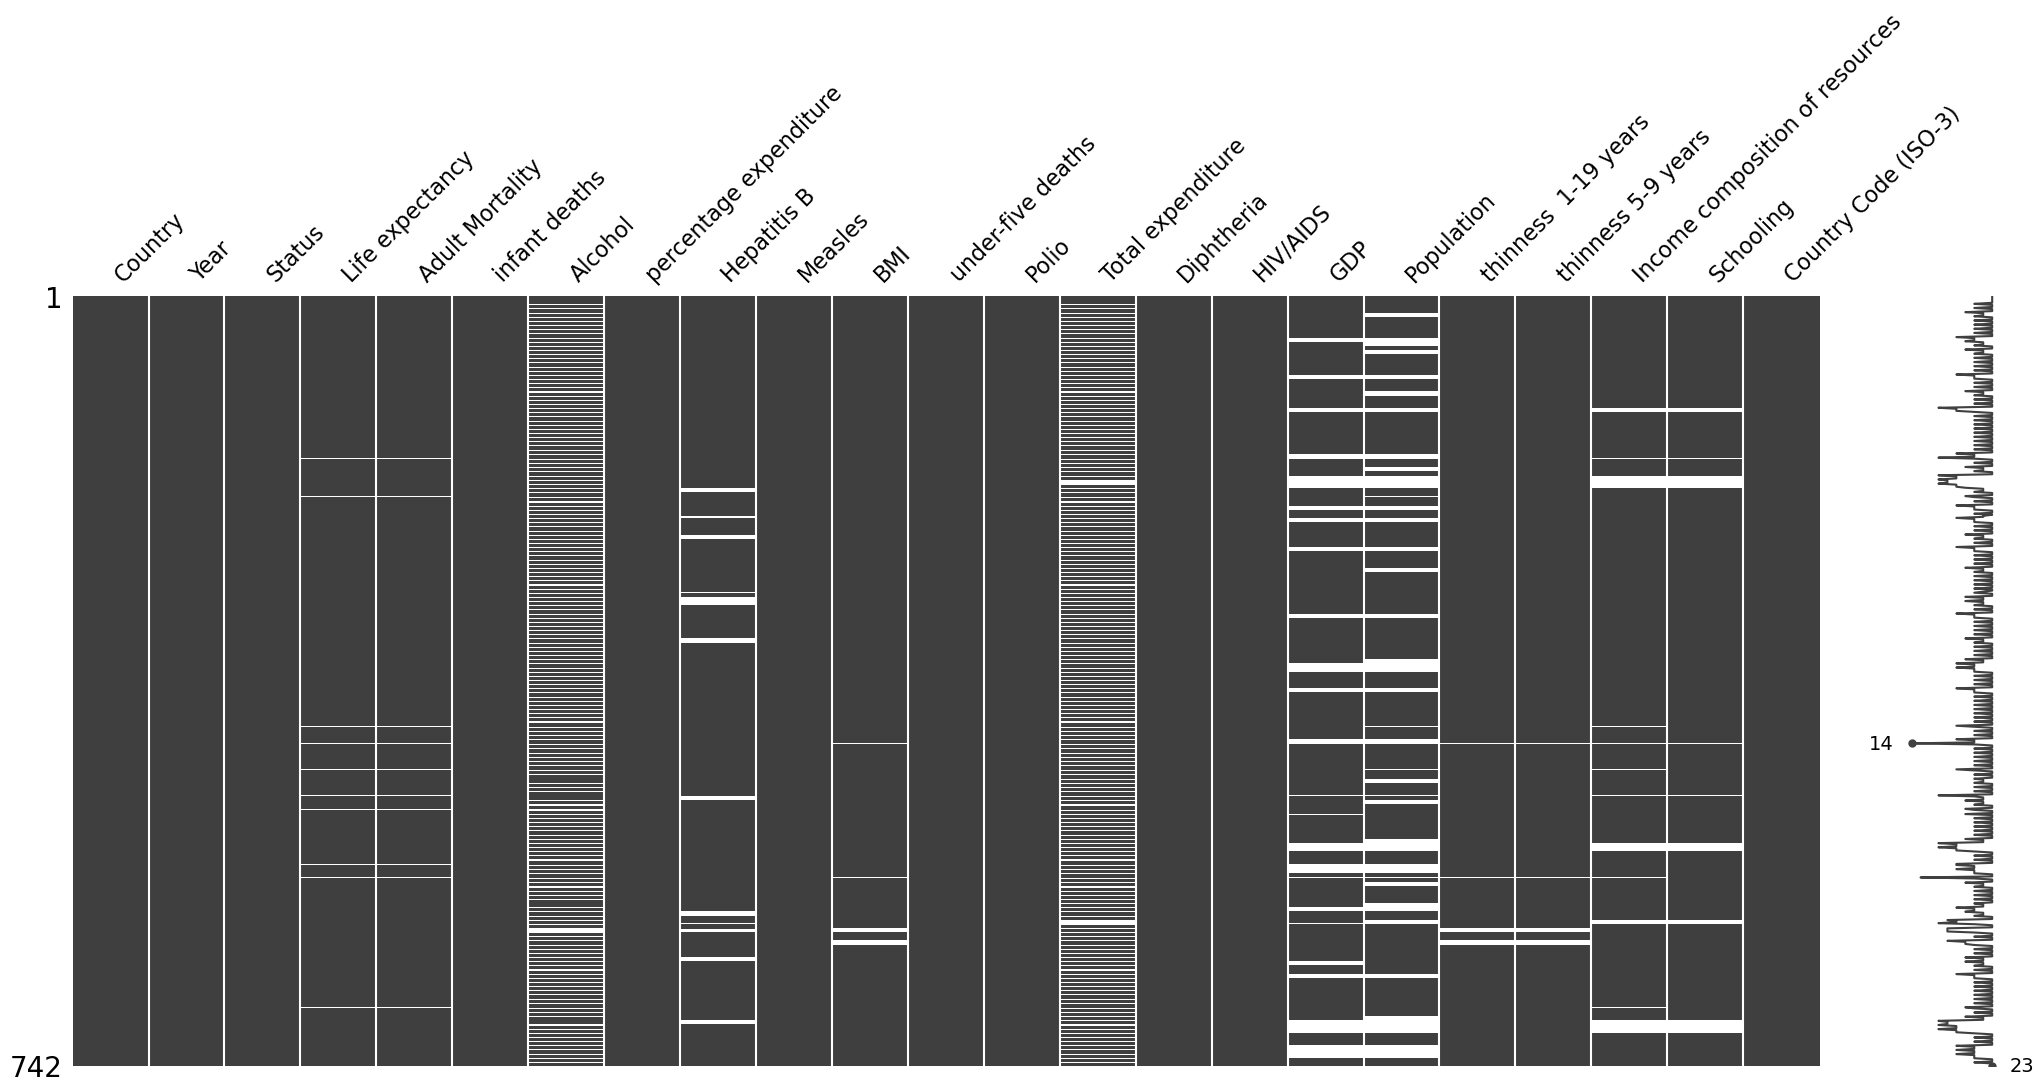

In [15]:
msno.matrix(df_2012)  # Visualizing existing and missing missing data in df_2012 using msno's nullity matrix

From visual inspection, we can see that ...TODO...